## World Happiness Report — Exploratory Data Analysis
Question: Is there a relationship between a country's happiness and its economy, and what could explain it?
Dataset: World Happiness Report 2015 (158 countries, Kaggle)

In [ ]:
import pandas as pd
df = pd.read_csv('2015.csv')
df.head()


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


There is a strong positive relationship (correlation = 0.78) between a country's economy and its happiness score — countries with a stronger economy tend to report higher happiness.

In [ ]:
print(df.shape)
df.info()


(158, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memor

Economy (0.78), Family (0.74), and Health (0.72) are all strongly linked to happiness — money is not the only factor, family and health matter almost as much.

In [ ]:
print(df.isnull().sum())
df.describe()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [ ]:
print(df[df['Economy (GDP per Capita)'] == 0][['Country','Happiness Score']])
print(df['Happiness Score'].corr(df['Economy (GDP per Capita)']))

              Country  Happiness Score
119  Congo (Kinshasa)            4.517
0.7809655268660212


One country, Congo (Kinshasa), had a suspicious value of 0 for economy, which is likely missing data rather than a real value. Removing it barely changes the correlation, confirming the result is reliable.

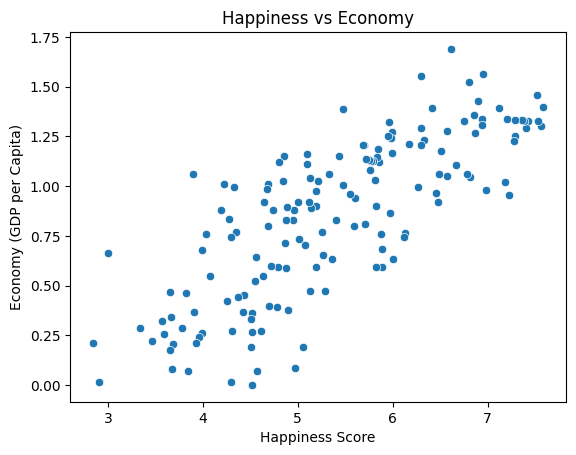

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Happiness Score', y='Economy (GDP per Capita)')
plt.title('Happiness vs Economy')
plt.show()

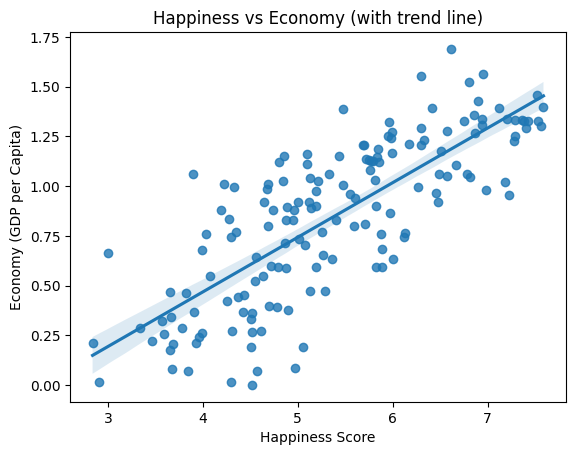

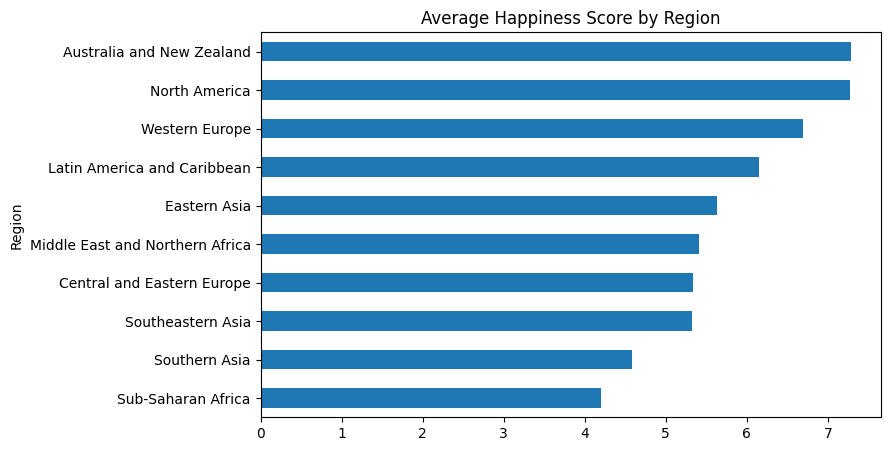

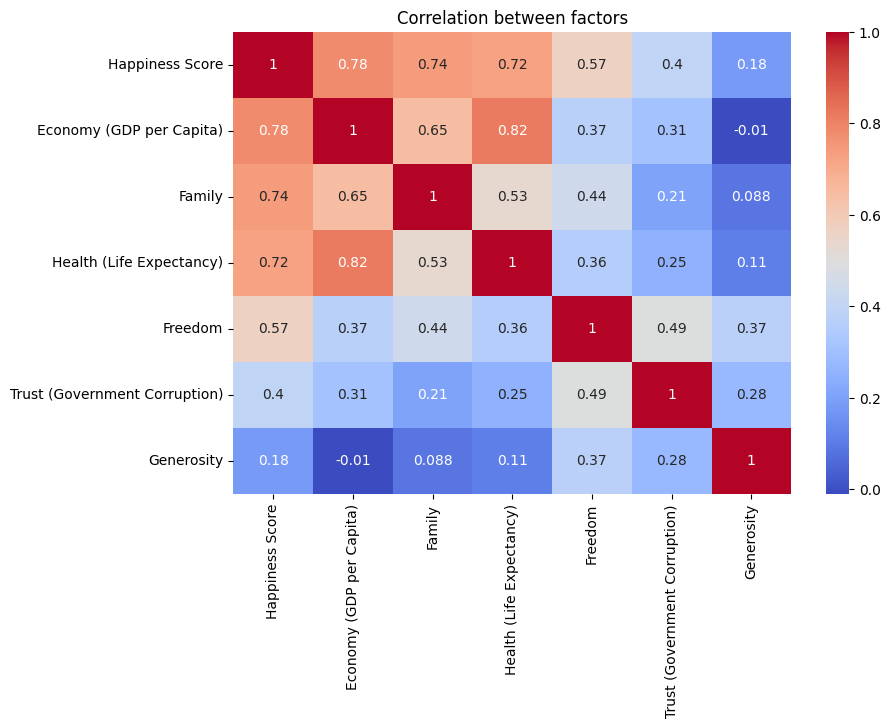

0.7834095321234088


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df, x='Happiness Score', y='Economy (GDP per Capita)')
plt.title('Happiness vs Economy (with trend line)')
plt.show()

region = df.groupby('Region')['Happiness Score'].mean().sort_values()
region.plot(kind='barh', figsize=(8,5), title='Average Happiness Score by Region')
plt.show()

cols = ['Happiness Score','Economy (GDP per Capita)','Family','Health (Life Expectancy)','Freedom','Trust (Government Corruption)','Generosity']
plt.figure(figsize=(9,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between factors')
plt.show()

clean = df[df['Economy (GDP per Capita)'] > 0]
print(clean['Happiness Score'].corr(clean['Economy (GDP per Capita)']))

Australia and New Zealand and North America have the highest average happiness scores, while Sub-Saharan Africa has the lowest.

## Conclusion
There is a strong link between a country's economy and its happiness (0.78), but Family and Health are nearly as important. This shows correlation, not causation — a country's happiness likely depends on multiple factors together, not economy alone.